In [ ]:
# 6.6. Beschaffung und Analyse von Zeitreihen

## 1. Import Biblioteken

In [37]:
# # Bibliotheken importieren

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')

In [38]:
# Bereinigten Datensatz laden

base_path = r"C:\Users\faink\Desktop\Achievement_6\02_data\2_cleaned"
plot_path = r"C:\Users\faink\Desktop\Achievement_6\05_visual"

In [39]:
from fredapi import Fred
import pandas as pd

fred = Fred(api_key="2ac8162b6e669d853e57a89c75202527")

# NROU Serien laden
data = fred.get_series("NROU")

data.head()

1949-01-01    5.255053
1949-04-01    5.261516
1949-07-01    5.268013
1949-10-01    5.274564
1950-01-01    5.281182
dtype: float64

## 2. In Datensatz umvandeln

In [40]:
df = pd.DataFrame(data, columns=["Value"])
df.index.name = "Date"
df.head()

,Value
Date,
1949-01-01,5.255053
1949-04-01,5.261516
1949-07-01,5.268013
1949-10-01,5.274564
1950-01-01,5.281182


## 3. Index zurücksetzen und subsetten (1980–2020)

In [41]:
data_2 = data.reset_index()

# Subset: 1980–2020

data_sub = data_2.loc[
    (data_2["Date"] >= "1980-01-01") &
    (data_2["Date"] < "2020-06-01")
]

# Datum wieder als Index setzen

data_sub["Date"] = pd.to_datetime(data_sub["Date"])
data_sub = data_sub.set_index("Date")

data_sub.head()

,0
Date,
1980-01-01,6.216387
1980-04-01,6.209639
1980-07-01,6.202295
1980-10-01,6.194459
1981-01-01,6.186199


## 4. Zeitreihe plotten

In [29]:
# Subset 1980–2020 bilden

data_sub = df.loc["1980-01-01":"2020-06-01"]

data_sub.head()

,Value
Date,
1980-01-01,6.216387
1980-04-01,6.209639
1980-07-01,6.202295
1980-10-01,6.194459
1981-01-01,6.186199


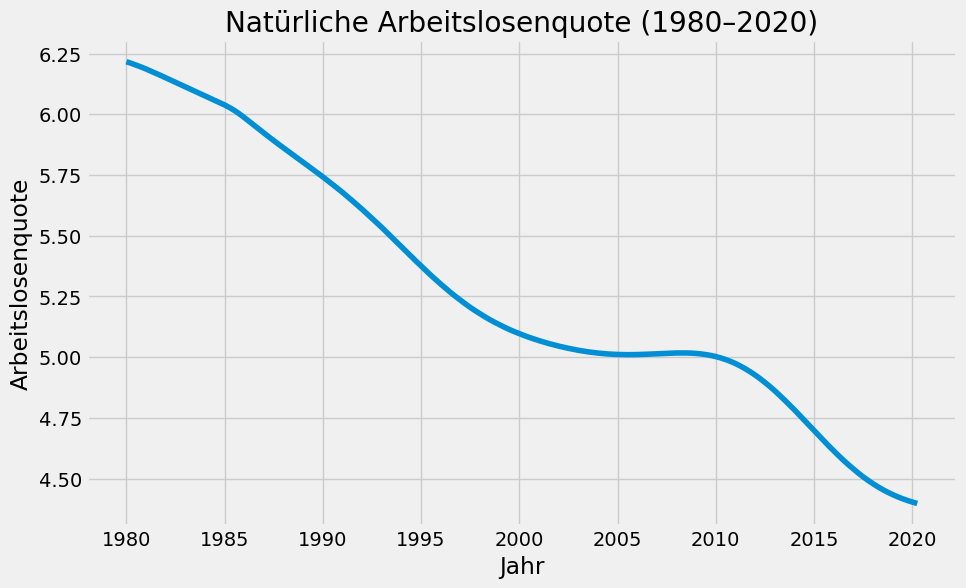

<Figure size 640x480 with 0 Axes>

In [31]:
# Zeitreihe plotten

plt.figure(figsize=(10,6))
plt.plot(data_sub.index, data_sub["Value"])
plt.title("Natürliche Arbeitslosenquote (1980–2020)")
plt.xlabel("Jahr")
plt.ylabel("Arbeitslosenquote")
plt.show()

plot_ts = os.path.join(plot_path, "zeitreihe_unemployment.png")
plt.savefig(plot_ts, dpi=300, bbox_inches="tight")


## 5. Zerlegung (Decomposition)


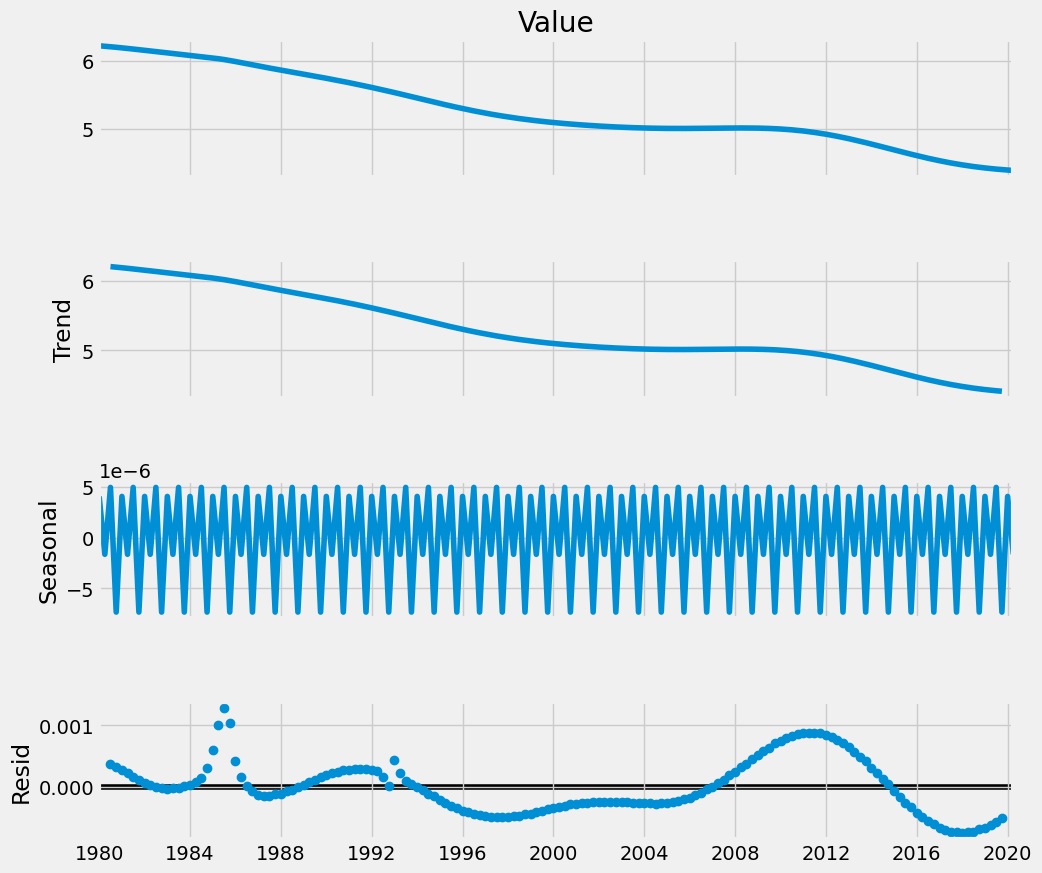

In [32]:
decomposition = sm.tsa.seasonal_decompose(data_sub["Value"], model="additive")

fig = decomposition.plot()
fig.set_size_inches(12, 10)

plot_decomp = os.path.join(plot_path, "zeitreihe_decomposition.png")
plt.savefig(plot_decomp, dpi=300, bbox_inches="tight")
plt.show()

## 6. Stationarität prüfen (ADF‑Test)

In [33]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data_sub["Value"])
print("ADF-Statistik:", result[0])
print("p-Wert:", result[1])

ADF-Statistik: -0.958910143716355
p-Wert: 0.7679544496285243


Interpretation:
- p < 0.05 → stationär
- p ≥ 0.05 → nicht stationär

## 7. Differenzierung (falls nicht stationär)

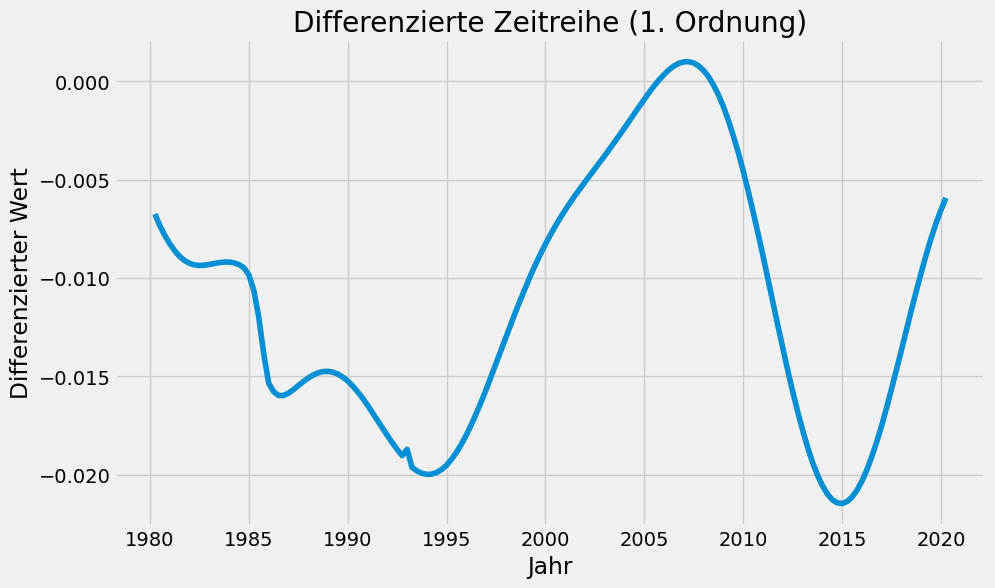

In [35]:
# Differenzierung (1. Ordnung)

data_diff = data_sub["Value"].diff().dropna()

plt.figure(figsize=(10,6))
plt.plot(data_diff)
plt.title("Differenzierte Zeitreihe (1. Ordnung)")
plt.xlabel("Jahr")
plt.ylabel("Differenzierter Wert")

plot_diff = os.path.join(plot_path, "zeitreihe_diff.png")
plt.savefig(plot_diff, dpi=300, bbox_inches="tight")
plt.show()

## 8. ADF-Testnach Differenzierung

In [36]:
result2 = adfuller(data_diff)
print("ADF-Statistik (diff):", result2[0])
print("p-Wert (diff):", result2[1])

ADF-Statistik (diff): -3.367041023230326
p-Wert (diff): 0.012135086329314084


## 9. Zeitreihenanalyse: Trend, Saisonalität und Stationarität

In dieser Analyse wurde die natürliche Arbeitslosenquote (FRED/NROU) als univariate Zeitreihe untersucht.  
Nach dem Laden und Subsetten der Daten (1980–2020) wurde die Reihe visualisiert und anschließend in ihre Komponenten zerlegt:

- **Trend:** zeigt einen langfristigen Rückgang der Arbeitslosenquote mit einem deutlichen Ausschlag während der Finanzkrise 2008/2009.  
- **Saisonalität:** regelmäßige Schwankungen, die sich über die Jahre wiederholen.  
- **Residuen:** zufällige Variabilität, die nicht durch Trend oder Saisonalität erklärt wird.

Der ADF‑Test zeigte, dass die ursprüngliche Reihe nicht stationär ist.  
Durch eine Differenzierung erster Ordnung wurde Stationarität erreicht, was eine wichtige Voraussetzung für spätere Prognosemodelle darstellt.

Diese Schritte bereiten die Daten optimal für die Zeitreihenprognose in der nächsten Lektion vor.

In [42]:
data_sub.to_csv(os.path.join(base_path, "data_sub.csv"), index=True)